<div style="margin-bottom: 32px;">
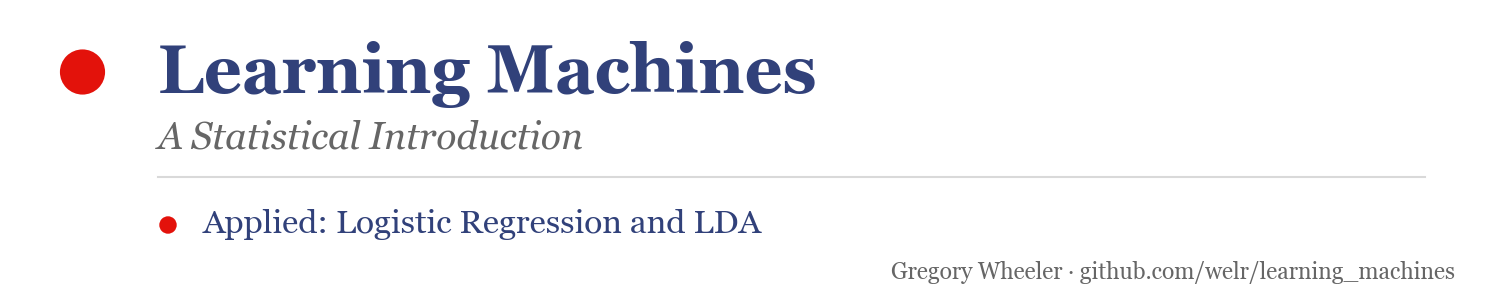
</div>


# Applied — Logistic Regression, Odds, and a Generative Cousin

A short companion to the classification chapter. We fit logistic regression to a real medical dataset, read its coefficients as **odds**, and then fit **linear discriminant analysis**—the *generative* counterpart to logistic regression's *discriminative* fit—to see how close the two land.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

plt.style.use("mlone_style.mplstyle"); mt.set_notebook_mode()
np.random.seed(0)

## The data: Pima diabetes

768 patients, eight routine measurements each—plasma glucose, blood pressure, BMI, age, and so on—and a label: did the patient test positive for diabetes? We standardize the features so each coefficient measures the effect of a one-standard-deviation change, which makes them comparable. (It is an old, slightly noisy dataset, used here only to read a fitted model.)

In [2]:
data = fetch_openml("diabetes", version=1, as_frame=True)
features = list(data.data.columns)
X = data.data.values.astype(float)
y = (data.target.values == "tested_positive").astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)
print(f"{len(X)} patients, {len(features)} features: {features}")

768 patients, 8 features: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']


## Logistic regression, read as odds

A logistic-regression coefficient is a change in *log-odds*; exponentiating it gives an **odds ratio**—the factor by which the odds of a positive test multiply for a one-standard-deviation rise in that feature (Chapter 4). Above one raises the odds; below one lowers them.

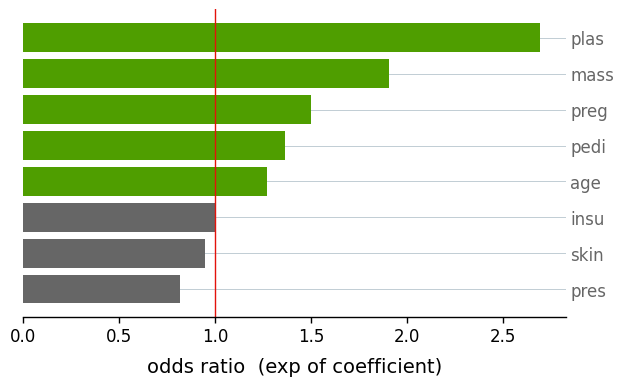

test accuracy: 0.781


In [3]:
logreg = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
odds = np.exp(logreg.coef_[0])
order = np.argsort(odds)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(features)), odds[order],
        color=[mt.GREEN if o > 1 else mt.GRAY for o in odds[order]])
ax.axvline(1.0, color=mt.RED, lw=1)
ax.set_yticks(range(len(features))); ax.set_yticklabels([features[i] for i in order])
ax.set_xlabel("odds ratio  (exp of coefficient)")
mt.apply_book_style(ax)
plt.show()
print(f"test accuracy: {logreg.score(X_te, y_te):.3f}")

## Discriminative versus generative

Logistic regression is **discriminative**: it models $P(y\mid\mathbf{x})$ directly. **Linear discriminant analysis** is its **generative** sibling—it models each class's feature distribution and applies Bayes' rule, which, under a shared Gaussian covariance, also yields a *linear* boundary (Chapter 4). On data like this the two land in nearly the same place.

In [4]:
lda = LinearDiscriminantAnalysis().fit(X_tr, y_tr)
print(f"logistic regression  test accuracy: {logreg.score(X_te, y_te):.3f}")
print(f"linear discriminant  test accuracy: {lda.score(X_te, y_te):.3f}")

logistic regression  test accuracy: 0.781
linear discriminant  test accuracy: 0.781


## Try next

- Which features raise the odds most, and do they match clinical intuition (glucose, BMI)?
- Refit *without* standardizing; the odds ratios now mix units (glucose in mg/dL, age in years) and are no longer comparable—why?
- The chapter's Ng–Jordan note says a generative model can win with little data and lose with much. Subsample the training set to a few dozen patients and see which classifier degrades less.